# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [1]:
# откройте данные: ваш код здесь
# Импорт библиотек
import pandas as pd
import numpy as np

# Импорт данных
data = pd.read_csv('data/spam_or_not_spam.zip')
data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [2]:
# рассчитайте частоты для классов : ваш код здесь
data['label'].value_counts()

label
0    2500
1     500
Name: count, dtype: int64

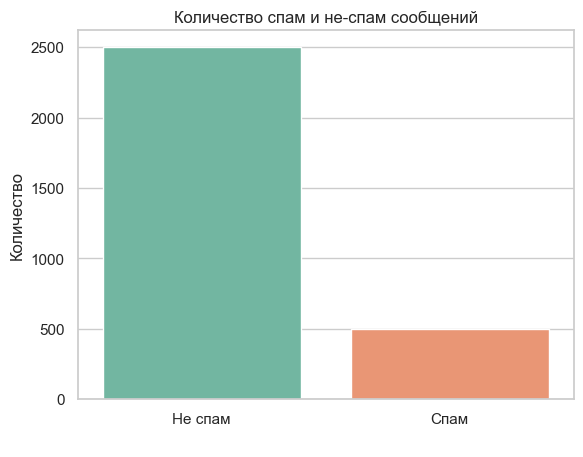

In [3]:
# визуализируйте результат: ваш код здесь
# Библиотека для визуализации
import seaborn as sns
sns.set_theme('notebook', style="whitegrid", palette="Set2")

# Визуализация
fig = sns.countplot(data=data, x='label')
fig.set_xticklabels(['Не спам', 'Спам'])
fig.set_title('Количество спам и не-спам сообщений')
fig.set_xlabel(' ')
fig.set_ylabel('Количество');

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [5]:
#ваш код здесь
data['email'] = data['email'].replace(['', ' ', None], np.nan)
data = data.dropna(subset=['email'])

Переводим данные в векторный вид:

In [6]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [7]:
#ваш код здесь
X.shape[1]

34116

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [8]:
#ваш код здесь
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [9]:
#ваш код здесь
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [10]:
#ваш код здесь
y_test.mean().round(3)

0.165

## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [11]:
#ваш код здесь
from sklearn import naive_bayes
model = naive_bayes.ComplementNB(alpha = 0.01)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [12]:
#ваш код здесь
from sklearn import metrics

print("= = = = = = Метрики на тренировочной выборке = = = = = =")
print(metrics.classification_report(y_train, y_train_predict, digits=3))

print("\n= = = = = = = Метрики на тестовой выборке = = = = = = =")
print(metrics.classification_report(y_test, y_test_predict, digits=3))

= = = = = = Метрики на тренировочной выборке = = = = = =
              precision    recall  f1-score   support

           0      0.999     1.000     1.000      1874
           1      1.000     0.997     0.999       373

    accuracy                          1.000      2247
   macro avg      1.000     0.999     0.999      2247
weighted avg      1.000     1.000     1.000      2247


= = = = = = = Метрики на тестовой выборке = = = = = = =
              precision    recall  f1-score   support

           0      0.986     1.000     0.993       626
           1      1.000     0.927     0.962       124

    accuracy                          0.988       750
   macro avg      0.993     0.964     0.978       750
weighted avg      0.988     0.988     0.988       750



Нарисуйте ROC-кривую:

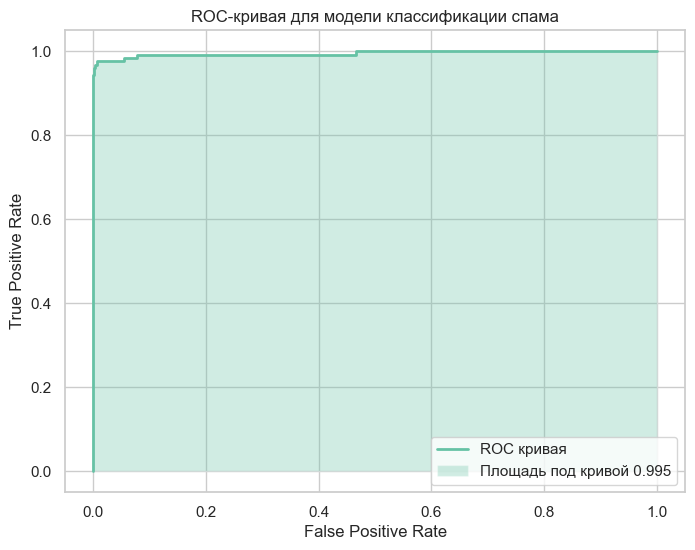

In [13]:
#ваш код здесь
import matplotlib.pyplot as plt
# Получаем вероятности для спама
y_test_proba = model.predict_proba(X_test)[:, 1]
# Рассчитываем ROC-кривую
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_proba)
roc_auc = metrics.roc_auc_score(y_test, y_test_proba)
# Визуализация
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label='ROC кривая')
plt.fill_between(fpr, tpr, alpha=0.3, label=f'Площадь под кривой {roc_auc:.3f}')
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для модели классификации спама');

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

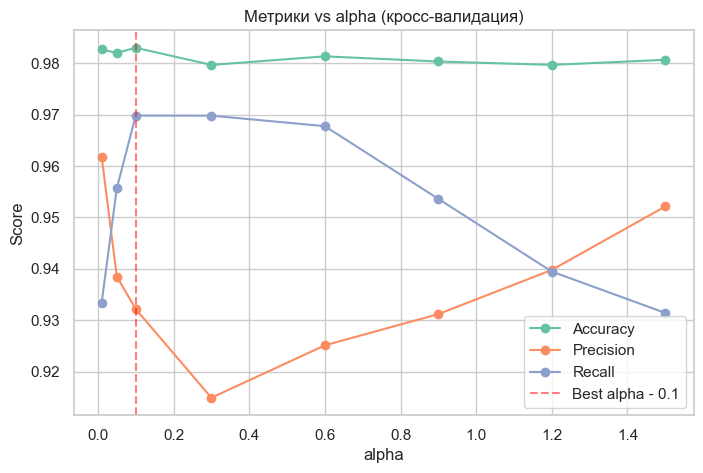

In [14]:
from sklearn.model_selection import cross_validate

alphas = [0.01, 0.05, 0.1, 0.3, 0.6, 0.9, 1.2, 1.5]
accuracy_scores = []
precision_scores = []
recall_scores = []

for alpha in alphas:
    model = naive_bayes.ComplementNB(alpha=alpha)
    cv_results = cross_validate(model, X, y, cv=5, 
                               scoring=['accuracy', 'precision', 'recall'])
    accuracy_scores.append(cv_results['test_accuracy'].mean())
    precision_scores.append(cv_results['test_precision'].mean())
    recall_scores.append(cv_results['test_recall'].mean())

# Лучший alpha по accuracy
best_idx = np.argmax(accuracy_scores)
best_alpha = alphas[best_idx]

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(alphas, accuracy_scores, 'o-', label='Accuracy')
plt.plot(alphas, precision_scores, 'o-', label='Precision')
plt.plot(alphas, recall_scores, 'o-', label='Recall')
plt.xlabel('alpha')
plt.ylabel('Score')
plt.title('Метрики vs alpha (кросс-валидация)')
plt.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.5, label=f'Best alpha - {best_alpha}')
plt.legend();

**Вывод:** Параметр alpha влияет на качество классификации. При alpha = 0.1 достигается максимальная accuracy и recall, что оптимально для задачи обнаружения спама — важно минимизировать пропущенные спам-письма. Если критично снизить количество ложных срабатываний (нормальные письма, помеченные как спам), следует выбрать alpha = 1.2, который обеспечивает баланс между precision и recall при сохранении высокой accuracy (0.98).

= = = = = = Метрики на тренировочной выборке = = = = = =
              precision    recall  f1-score   support

           0      0.999     1.000     0.999      1874
           1      1.000     0.995     0.997       373

    accuracy                          0.999      2247
   macro avg      0.999     0.997     0.998      2247
weighted avg      0.999     0.999     0.999      2247


= = = = = = = Метрики на тестовой выборке = = = = = = =
              precision    recall  f1-score   support

           0      0.995     0.998     0.997       626
           1      0.992     0.976     0.984       124

    accuracy                          0.995       750
   macro avg      0.994     0.987     0.990       750
weighted avg      0.995     0.995     0.995       750



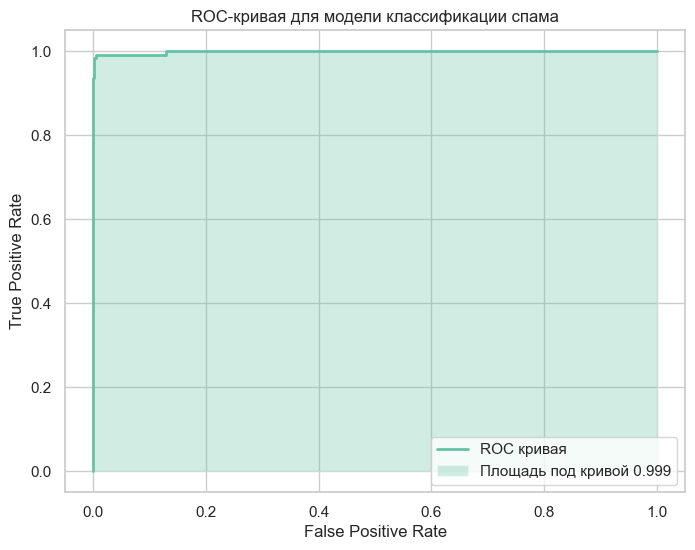

In [15]:
# Модель на лучшей альфа
model = naive_bayes.ComplementNB(alpha = 0.1)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
print("= = = = = = Метрики на тренировочной выборке = = = = = =")
print(metrics.classification_report(y_train, y_train_predict, digits=3))
y_test_predict = model.predict(X_test)
print("\n= = = = = = = Метрики на тестовой выборке = = = = = = =")
print(metrics.classification_report(y_test, y_test_predict, digits=3))

# Получаем вероятности для положительного класса (спама)
y_test_proba = model.predict_proba(X_test)[:, 1]
# Рассчитываем ROC-кривую
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_proba)
roc_auc = metrics.roc_auc_score(y_test, y_test_proba)
# Визуализация
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC кривая')
plt.fill_between(fpr, tpr, alpha=0.3, label=f'Площадь под кривой {roc_auc:.3f}')
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для модели классификации спама');

Модель с alpha = 0.1 показывает лучшее качество и менее переобучена. AUC увеличился с 0.995 до 0.999, accuracy выросла с 0.988 до 0.995, а recall для спама значительно улучшился с 0.927 до 0.976 при сохранении высокой точности precision 0.992. Модель стала эффективнее обнаруживать спам с минимальным увеличением ложных срабатываний.